In [1]:
%load_ext autoreload
%autoreload 2
import sys
import os
import warnings
warnings.simplefilter("ignore")
from herculens_import_main import *
import jax
import numpyro
jax.config.update('jax_enable_x64', True)
numpyro.enable_x64()

os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
os.environ['XLA_FLAGS'] = (
    '--xla_gpu_enable_triton_softmax_fusion=true '
    '--xla_gpu_triton_gemm_any=True '
    '--xla_gpu_enable_async_collectives=true '
    '--xla_gpu_enable_latency_hiding_scheduler=true '
    '--xla_gpu_enable_highest_priority_async_stream=true '
)
if 'graphviz' not in os.environ['PATH']:
    os.environ['PATH'] = '/opt/apps/pkgs/graphviz/12.2.1/intel64/gnu_12.2.0/bin:' + os.environ['PATH']

[CudaDevice(id=0)]


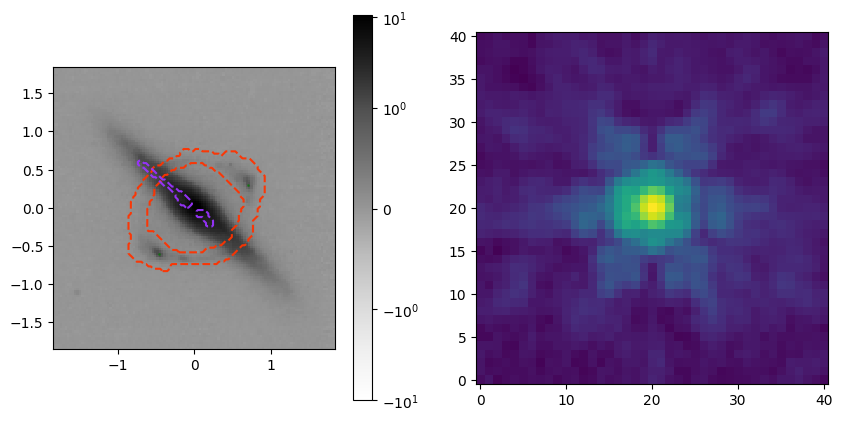

In [2]:
pix_scale = 0.031        # arcsec / pixel
exposure_time = 3736.39     # seconds

DIR = "../Data/LensedEdgeON/"
cutout_size = 60
data  = jnp.array(fits.getdata(DIR+"cutout.fits")[920 - cutout_size:920+cutout_size,920-cutout_size:920+cutout_size])
error = jnp.array(fits.getdata(DIR+"error.fits")[920 - cutout_size:920+cutout_size,920-cutout_size:920+cutout_size])
mask  = jnp.array(1-fits.getdata(DIR+"mask-cutout.fits")[920 - cutout_size:920+cutout_size,920-cutout_size:920+cutout_size],dtype = 'bool')
mask_out = jnp.array(fits.getdata(DIR+"mask_dust-cutout.fits")[920 - cutout_size:920+cutout_size,920-cutout_size:920+cutout_size],dtype = 'bool')
psf_jwst   = fits.getdata(DIR+"psf_0001_cutout.fits")

pixel_grid, xgrid, ygrid, x_axis, y_axis, extent, nx, ny = get_pixel_grid(data, pix_scale)
mean, rms, background_pixels = reduce_bg(data, corner_pixel = 10)
data = data - mean

psf = PSF(psf_type='PIXEL', kernel_point_source = psf_jwst)
provided_rms = True
noise = Noise(nx, ny, exposure_time=exposure_time)

N_gauss_light = 20
N_gauss_source = 2
sigma_lims_lens = [1e-2, 1.2]
sigma_lims = [0.01, 0.1]
halfrange = [0.1, 0.1, 0.1]
source_grid_scale = 1
conj_points = jnp.array(
    [
        [0.7, 0.3],
        [-0.46, -0.60],
    ],
    dtype=jnp.float64,
)

ss_factor = 2
plt.figure(figsize = (10,5))
plt.subplot(1,2,1)
plt.imshow(data, origin='lower', cmap='Grays', extent=extent, norm=colors.SymLogNorm(linthresh = 1, vmax = 10.5, vmin = -10))
plt.colorbar();
plt.contour(mask, levels=[0.5], colors='#ff3300', alpha = 0.95, linewidth = 2, linestyles='dashed', origin='lower', extent=extent)
plt.contour(mask_out, levels=[0.5], colors='#9933ff', alpha = 0.95, linestyles='dashed', origin='lower', extent=extent)
plt.plot(conj_points[:, 0], conj_points[:, 1], 'o', alpha = 0.5, markersize = 1, color='green')
plt.subplot(1,2,2)
plt.imshow(psf_jwst, norm = "log")

In [3]:
mass_model = MassModel(['EPL', 'SHEAR'])

lens_light_model = LightModel(['MULTI_GAUSSIAN_ELLIPSE'],{})

source_light_model = LightModel(['MULTI_GAUSSIAN_ELLIPSE'],{})


lens_image = LensImageExtension(
    pixel_grid,
    psf,
    noise_class=noise,
    lens_light_model_class=lens_light_model,
    lens_mass_model_class=mass_model,
    source_model_class=source_light_model,
    source_arc_mask=mask,
    conjugate_points=conj_points,
    kwargs_numerics={'supersampling_factor': ss_factor},
    source_grid_scale = source_grid_scale
)

In [4]:
npix = int(mask_out.sum())
def model(data, N_gauss_light=N_gauss_light, conj = True, provided_rms = False):
    mass_params = EPL_w_shear('Mass model', '1', theta_low = 0.5, theta_high = 1.5, gamma_up = 2.4 ,gamma_low = 1.6)
    lens_light = multi_gauss_light('Lens light', 'lens', N_gauss_light, sigma_lims = sigma_lims_lens,center_low=-0.2,center_high=0.2, e_low = -1, e_high = 1)

    conj_points = lens_image.trace_conjugate_points(mass_params)
    conj_mean = conj_points.mean(axis=0)
    source_light = multi_gauss_light('Source light', 'source', N_gauss_source, sigma_lims, center_high = 0.2, center_low = -0.2)

    conj_distance = reduced_distance_matrix(conj_points)
    nc = conj_distance.shape[0]

    if conj:
        with numpyro.plate(f'Conjugate points 2 - [{nc}]', nc):
            numpyro.sample('conjugate_points', dist.Exponential(1000), obs=conj_distance)

    model_image = lens_image.model(kwargs_lens=mass_params, kwargs_source=source_light, kwargs_lens_light=lens_light)

    model_std = error
    model_image_masked_out = model_image[mask_out]
    model_std_masked_out = model_std[mask_out]


    with numpyro.plate(f'Data masked - [{npix}]', npix):
        numpyro.sample('obs', dist.Normal(model_image_masked_out, model_std_masked_out), obs=data[mask_out])


def params2kwargs(params, fixed_params={}):
    params_full = params | fixed_params
    kwargs_lens = params2kwargs_EPL_w_shear(params_full, '1')
    center = lens_image.trace_conjugate_points(kwargs_lens).mean(axis=0)
    kwargs_lens_light = params2kwargs_multi_gauss_light(params_full, 'lens')
    return {
        'kwargs_lens': kwargs_lens,
        'kwargs_source': params2kwargs_multi_gauss_light(params_full, 'source'),
        'kwargs_lens_light': kwargs_lens_light
    }

model_graph = numpyro.render_model(model, model_args=(data,), render_distributions=True)


Running for 10,000 iterations:   0%|          | 0/10000 [00:00<?, ?it/s]

Running for 10,000 iterations:   0%|          | 0/10000 [00:00<?, ?it/s]

Running for 10,000 iterations:   0%|          | 0/10000 [00:00<?, ?it/s]

Running for 10,000 iterations:   0%|          | 0/10000 [00:00<?, ?it/s]

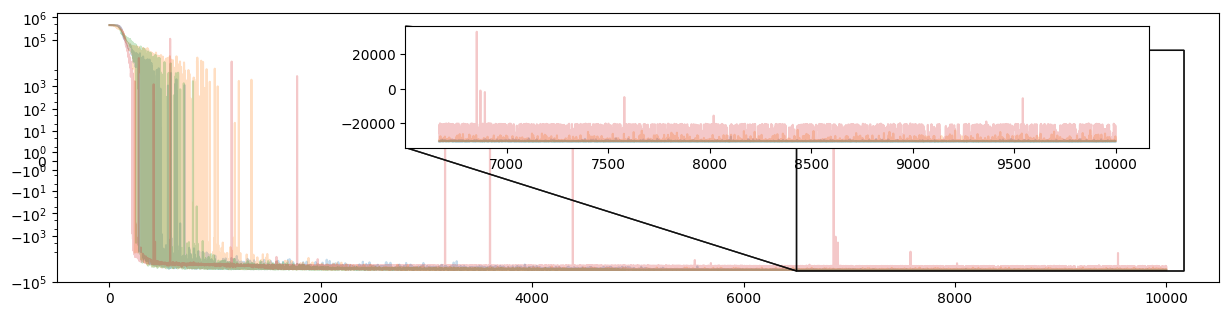

In [5]:
max_iterations = 10000
num_chains = 4

init_fun = infer.init_to_median(num_samples=25)
guide = autoguide.AutoLowRankMultivariateNormal(model, init_loc_fn=init_fun)
scheduler = split_scheduler(max_iterations, init_value=0.01, transition_steps=[200, 10])
optim = optax.adabelief(learning_rate=scheduler)
loss = infer.Trace_ELBO (num_particles=1)

rng_key = jax.random.PRNGKey(10)
rng_key, rng_key_ = jax.random.split(rng_key)
svi_keys = jax.random.split(rng_key_, num_chains)
svi = SVI_vec(model, guide, optim, loss)
multi_svi_results = svi.run(rng_key, num_chains, max_iterations, data, provided_rms = provided_rms, stable_update = True)
multi_svi_median = guide.median(multi_svi_results.params)
multi_svi_median_herc = median_params2kwargs(params2kwargs, multi_svi_median, jnp.arange(num_chains))

_, ax = plt.subplots(figsize=(15, 3.5))
axins = ax.inset_axes([0.3, 0.5, 0.64, 0.45])

for losses in multi_svi_results.losses:
    _ = plot_loss(losses, max_iterations, ax=ax, axins=axins, alpha=0.25)

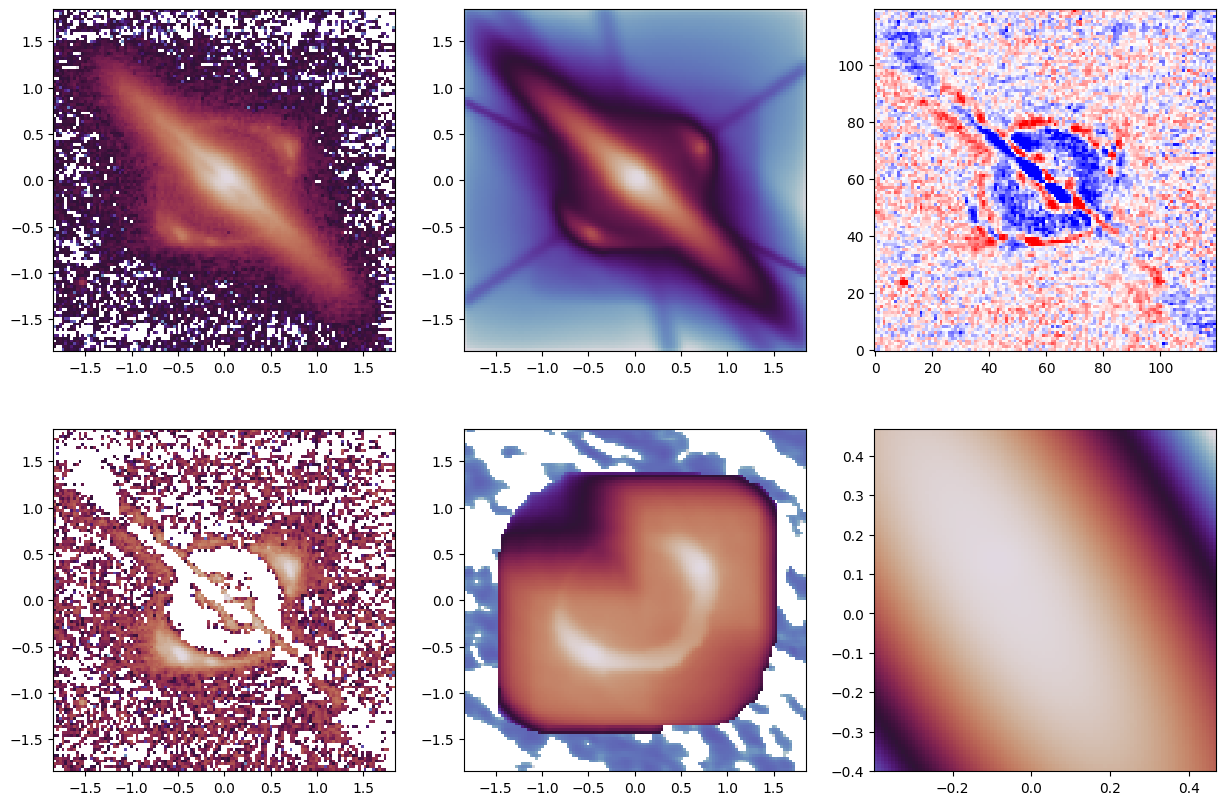

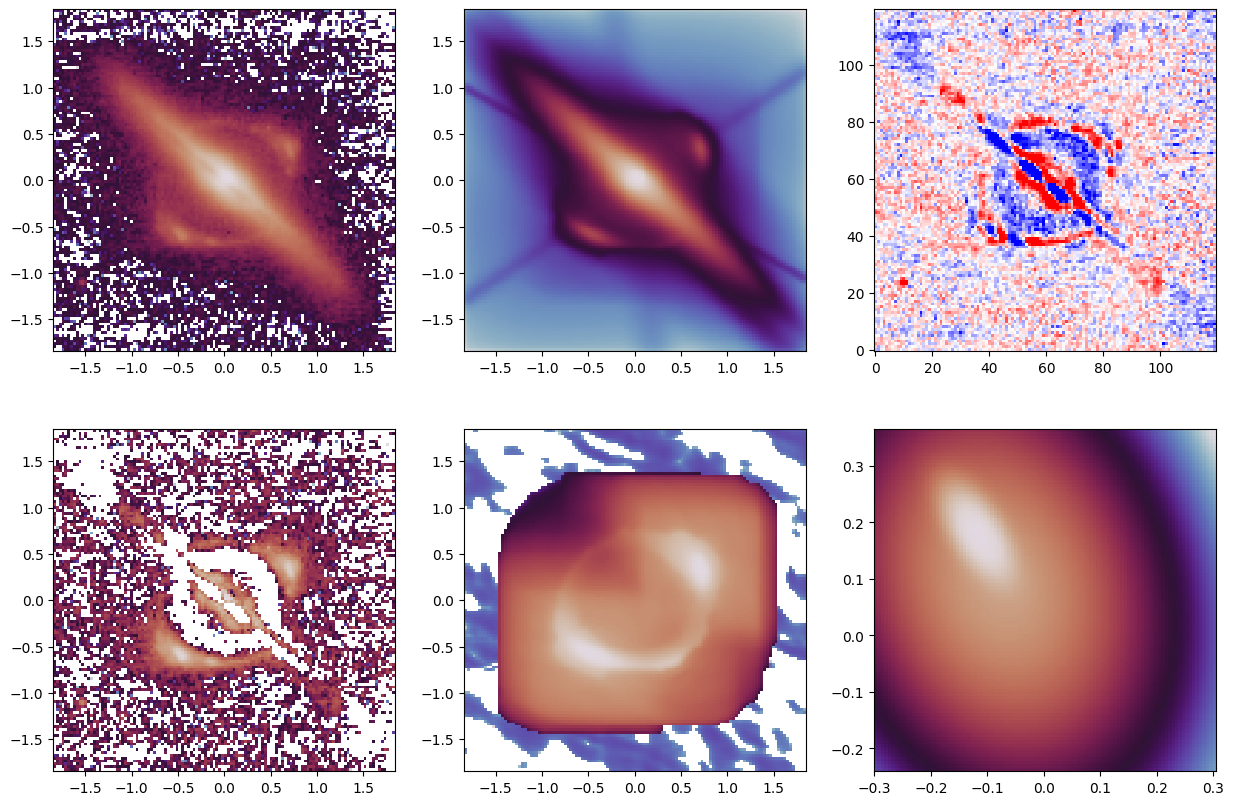

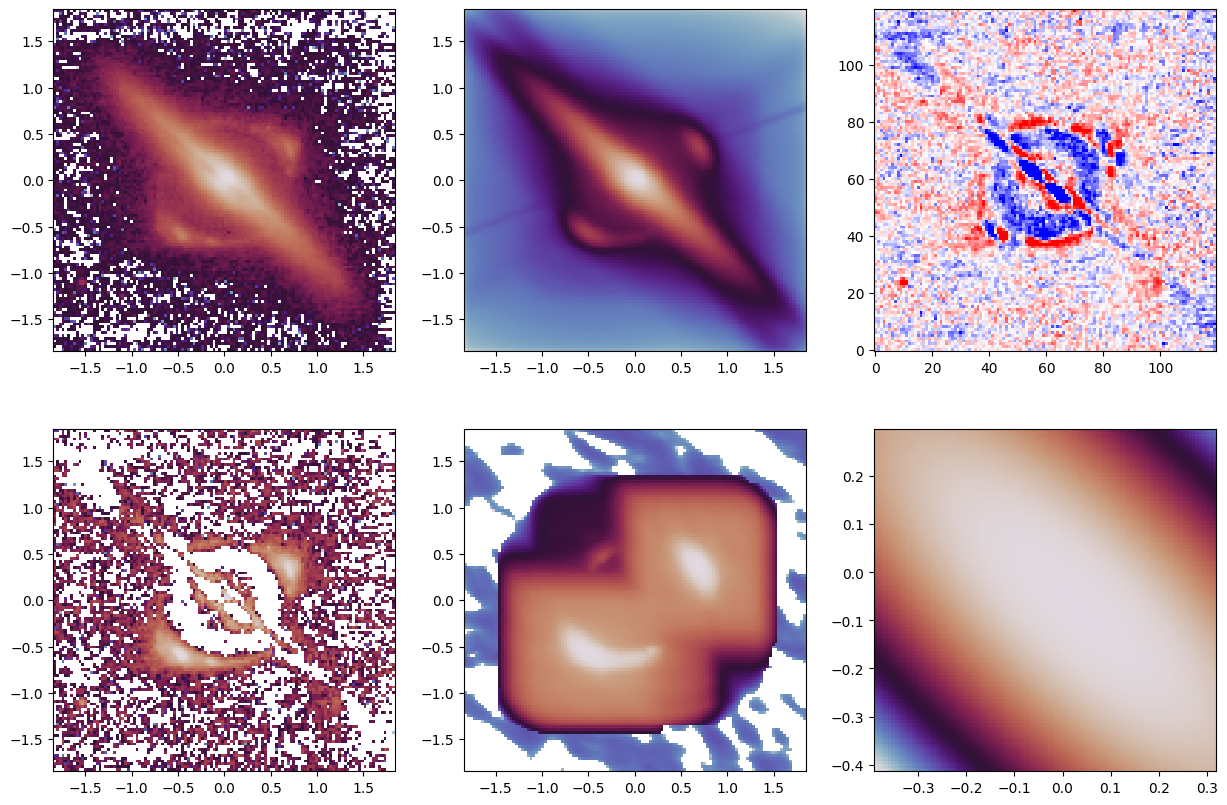

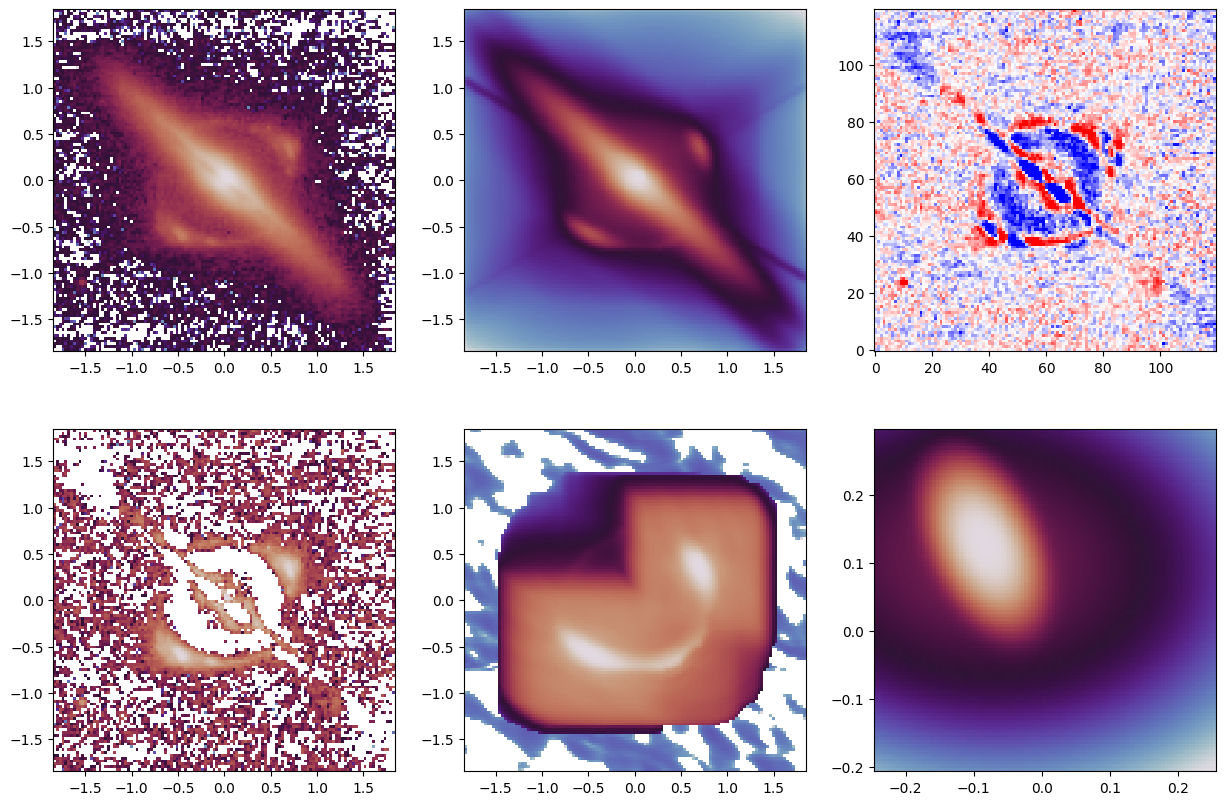

In [6]:
from lens_images_extension import pixelize_plane as pixelize_plane_single
for i in range(4):
    plt.figure(figsize = (15,10))
    plt.subplot(2,3,1)
    plt.imshow(data, norm = 'log', cmap = 'twilight', extent = extent, origin = 'lower')
    plt.subplot(2,3,2)
    image_model = lens_image.model(**get_value_from_index(multi_svi_median_herc, i), source_add = True)

    plt.imshow(image_model, norm = 'log', cmap = 'twilight', extent = extent)
    plt.subplot(2,3,3)
    plt.imshow((data - image_model)/error, cmap = 'bwr', vmax = 3, vmin = -3)
    plt.subplot(2,3,4)
    lens_light = lens_image.model(**get_value_from_index(multi_svi_median_herc, i), source_add = False)
    plt.imshow(data - lens_light, norm = 'log', cmap = 'twilight', extent = extent)

    plt.subplot(2,3,5)
    plt.imshow(image_model - lens_light, norm = 'log', cmap = 'twilight', extent = extent)
    plt.subplot(2,3,6)
    source, source_extent = pixelize_plane_single(
        lens_image,
        get_value_from_index(multi_svi_median_herc, i),
        100,
    )
    plt.imshow(source, extent = source_extent, norm = 'log', cmap = 'twilight')

In [8]:
best_pix_sizes = np.array([
    get_best_pixel_size(
        lens_image,
        get_value_from_index(multi_svi_median_herc, i),
        source_grid_scale
    ) for i in range(num_chains)
])
pixel_grid_shape = np.median(best_pix_sizes).astype(int)*1
# pixel_grid_shape = 250
print(pixel_grid_shape)

217


In [9]:
vars_mass = ['theta_E_1', 'gamma_1', 'e_1', 'center_1', 'gamma_sheer_1']
vars_lens_light = ['A_lens', 'sigma_lens','e_lens', 'center_lens']
vars_source_light = ['A_source', 'sigma_source', 'e_source']
vars_other = []

svi_samples = guide.sample_posterior(rng_key_, multi_svi_results.params, sample_shape=(1000,))
svi_samples_chains = jax.tree.map(lambda x: jnp.swapaxes(x, 0, 1), svi_samples)
svi_samples_chains = jax.device_get(svi_samples_chains)
multi_svi_guide_sample = az.from_dict(svi_samples_chains)

k_grid = K_grid((pixel_grid_shape, pixel_grid_shape))

@jax.vmap
def get_image(idx):
    i, _ = pixelize_plane_single(lens_image, get_value_from_index(multi_svi_median_herc, idx), pixel_grid_shape, source_grid_scale=source_grid_scale)
    return i
orig_source = get_image(jnp.arange(num_chains))
ps_keys = jax.random.split(rng_key_, num_chains)
from herculens_import_main import source_power_spectrum
ps_fits = source_power_spectrum(orig_source, ps_keys, None, False)

multi_svi_median_pixelated = {k: multi_svi_median[k] for k in vars_lens_light + vars_mass + vars_other} | ps_fits

In [10]:
k_grid = K_grid((pixel_grid_shape, pixel_grid_shape))

mass_model_pixel = MassModel(['EPL', 'SHEAR'])
lens_light_model_pixel = LightModel(['GAUSSIAN_ELLIPSE'] * N_gauss_light)

# source_light_model_pixel = LightModel(
#     ['PIXELATED', 'MULTI_GAUSSIAN_ELLIPSE'],
#     pixel_adaptive_grid=True,
#     pixel_interpol='fast_bilinear',
#     kwargs_pixelated={'num_pixels': pixel_grid_shape}
# )

source_light_model_pixel = LightModel(
    ['PIXELATED',],
    pixel_adaptive_grid=True,
    pixel_interpol='fast_bilinear',
    kwargs_pixelated={'num_pixels': pixel_grid_shape}
)


lens_image_pixel = LensImageExtension(
    deepcopy(pixel_grid),
    deepcopy(psf),
    noise_class=noise,
    lens_light_model_class=lens_light_model_pixel,
    lens_mass_model_class=mass_model_pixel,
    source_model_class=source_light_model_pixel,
    source_arc_mask=mask,
    conjugate_points=conj_points,
    kwargs_numerics={'supersampling_factor': ss_factor},
    source_grid_scale=source_grid_scale,
)

In [11]:
npix = int(mask_out.sum())
def model_pixel_full(data, k_values, N_gauss_light=N_gauss_light, conj=False, n_value = None):
    mass_params = EPL_w_shear('Mass model', '1', theta_low = 1.8, theta_high = 2.2, gamma_up = 2.6 ,gamma_low = 1.4)
    lens_light = gauss_light('Lens light', 'lens', N_gauss_light, sigma_lims = sigma_lims_lens,center_low=-0.4,center_high=0.4)
    
    if conj:
        conj_points = lens_image_pixel.trace_conjugate_points(mass_params)
        conj_distance = reduced_distance_matrix(conj_points)
        nc = conj_distance.shape[0]
        with numpyro.plate(f'Conjugate points 2 - [{nc}]', nc):
            numpyro.sample('conjugate_points', dist.Exponential(1000), obs=conj_distance)

    source_light = [
        matern_power_spectrum('Source grid', 'source_grid', k_values, n_value = n_value, positive = False),
        #multi_gauss_light('Source light', 'source', 1, sigma_lims)[0]
    ]

    pic = lens_image_pixel.model(
        kwargs_lens=mass_params,
        kwargs_source=source_light,
        kwargs_lens_light=lens_light,supersampled=True,unconvolved = True
    ).reshape(reshape_size,reshape_size)

    model_image = fftconvolve(pic, psf.kernel_point_source, mode='same')
    # model_image = re_size(img_conv, 2)
    
    model_std = rms_file
            
    model_image_masked_out = model_image[mask_out]
    model_std_masked_out = model_std[mask_out]

    with numpyro.plate(f'Data masked - [{npix}]', npix):
        numpyro.sample('obs', dist.Normal(model_image_masked_out, model_std_masked_out), obs=data[mask_out])


def params2kwargs_pixel(params, fixed_params={}):
    params_full = params | fixed_params
    kwargs_lens = params2kwargs_EPL_w_shear(params_full, '1')
    kwargs_source = [
                    params2kwargs_power_spectrum(params, 'source_grid'),
                    #params2kwargs_multi_gauss_light(params_full, 'source',sigma_lims)[0]
                    ]
    kwargs_lens_light = params2kwargs_gauss_light(params_full, 'lens', N_gauss_light, sigma_lims_lens)
    return {
        'kwargs_lens': kwargs_lens,
        'kwargs_source': kwargs_source,
        'kwargs_lens_light': kwargs_lens_light
    }

model_graph = numpyro.render_model(
    model_pixel_full,
    model_args=(data, k_grid.k),
    model_kwargs={'conj': False},
    render_distributions=True
)
#model_graph.unflatten(stagger=2)

[2026-01-31 14:40:52] running
SVI runs for 120.002 s which is 2.0 min


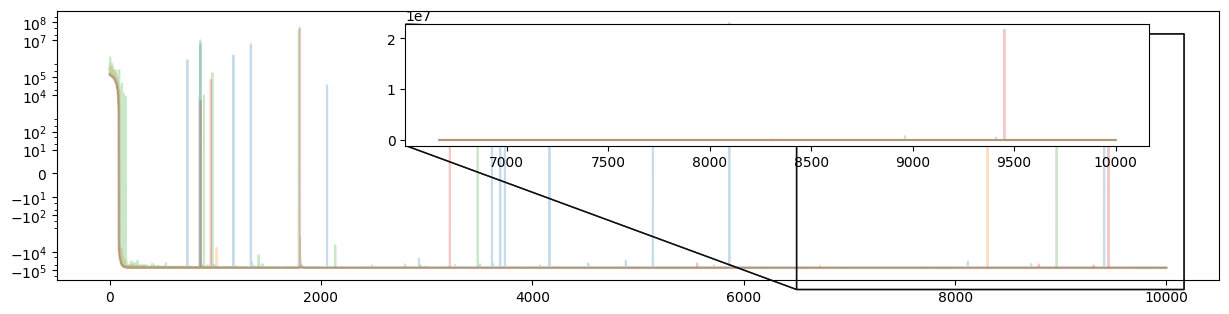

In [12]:
import time
import threading

def periodic_printer(interval, stop_event):
    while not stop_event.is_set():
        time.sleep(interval)
        print(f"[{time.strftime('%Y-%m-%d %H:%M:%S')}] running")
        
stop_event = threading.Event()
printer_thread = threading.Thread(target=periodic_printer, args=(120, stop_event), daemon=True)
printer_thread.start()
start = time.time()
###############################################################################################################################
max_iterations = 10000
num_chains = 4

init_fun = init_to_value_or_defer(values=get_value_from_index(multi_svi_median_pixelated, 1))
guide_pixel = autoguide.AutoDiagonalNormal(model_pixel_full,init_loc_fn=init_fun,init_scale=0.01)

scheduler = split_scheduler(max_iterations,init_value=0.01,transition_steps=[200, 10])
optim = optax.adabelief(learning_rate=scheduler)
loss = infer.TraceMeanField_ELBO()

@jax.vmap
def map_svi_pixel(key, i):
    init_fun = init_to_value_or_defer(values=get_value_from_index(multi_svi_median_pixelated, i))
    guide_pixel.init_loc_fn = init_fun
    svi_pixel = infer.SVI(model_pixel_full,guide_pixel,optim,loss)
    return svi_pixel.run(key, max_iterations, data, k_grid.k, conj=True, n_value = None,  progress_bar=False, stable_update=True)

svi_keys = jax.random.split(rng_key_, num_chains)
multi_svi_pixel_results = map_svi_pixel(svi_keys, jnp.arange(num_chains))
multi_svi_pixel_median = guide_pixel.median(multi_svi_pixel_results.params)
multi_svi_pixel_median_herc = median_params2kwargs(params2kwargs_pixel,multi_svi_pixel_median,jnp.arange(num_chains))

stop_event.set()
printer_thread.join()
end = time.time()
print(f"SVI runs for {end - start:.3f} s which is {(end - start)/60:.1f} min")

if plotit:
    _, ax = plt.subplots(figsize=(15, 3.5))
    axins = ax.inset_axes([0.3, 0.5, 0.64, 0.45])
    
    for losses in multi_svi_pixel_results.losses:
        _ = plot_loss(losses, max_iterations, ax=ax, axins=axins, alpha=0.25)

#383 source pixels: 6120s

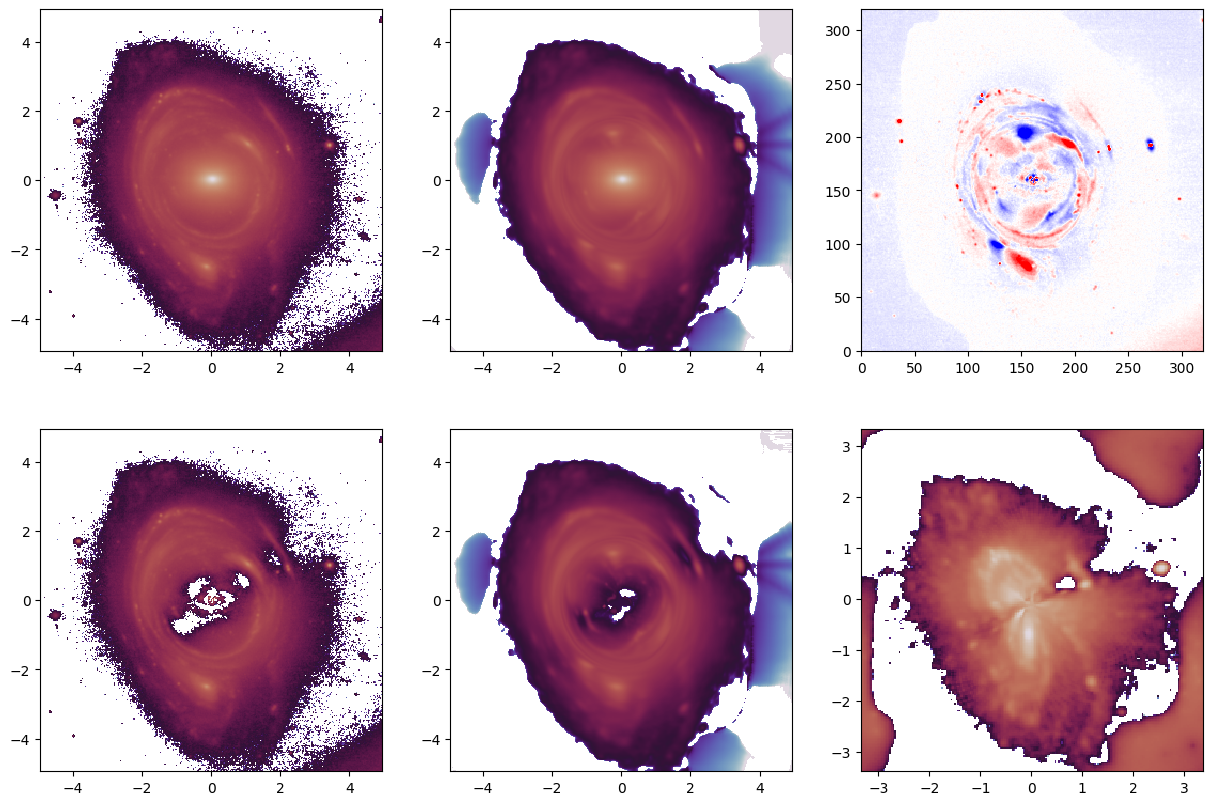

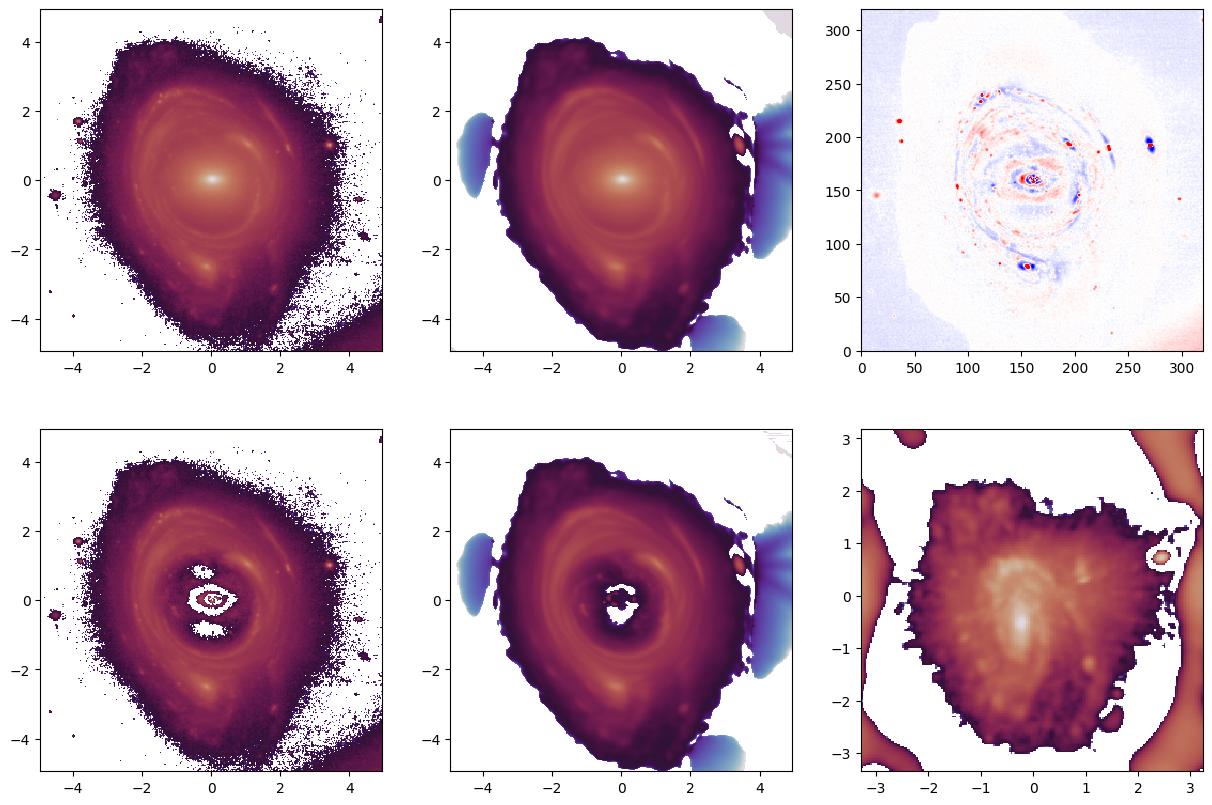

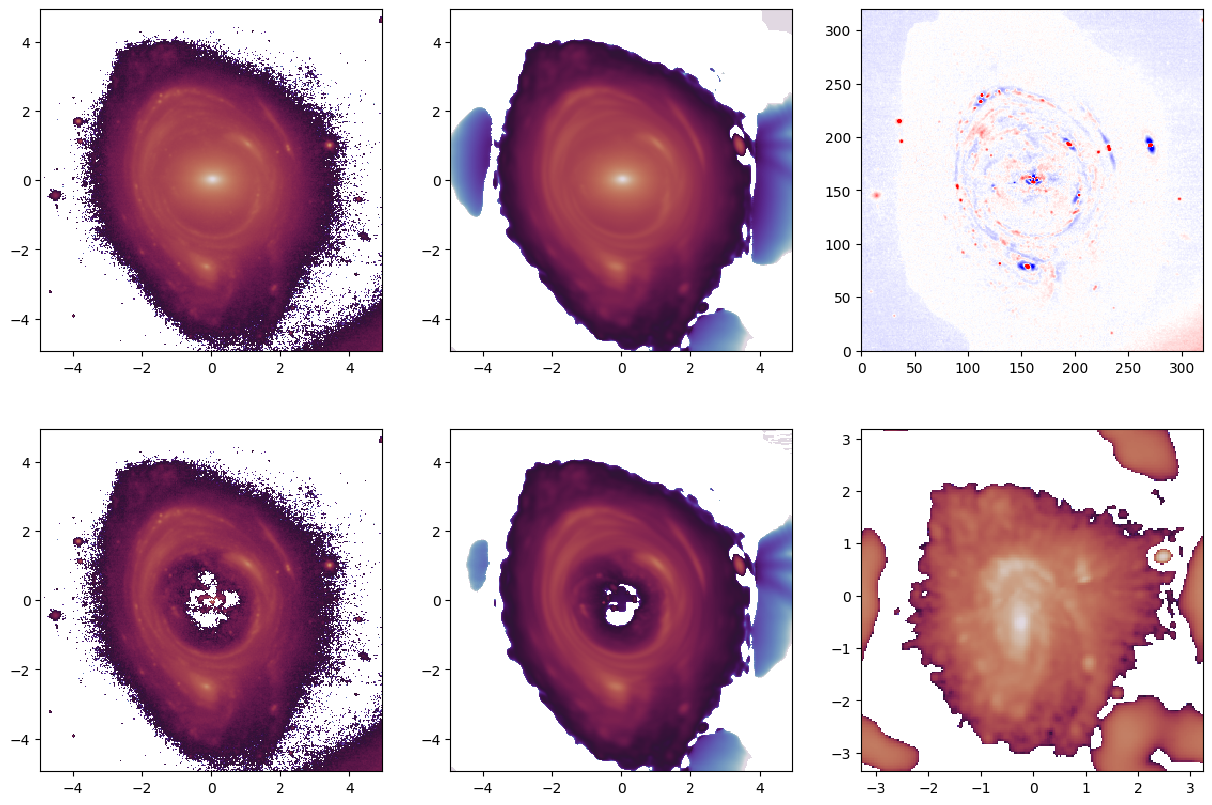

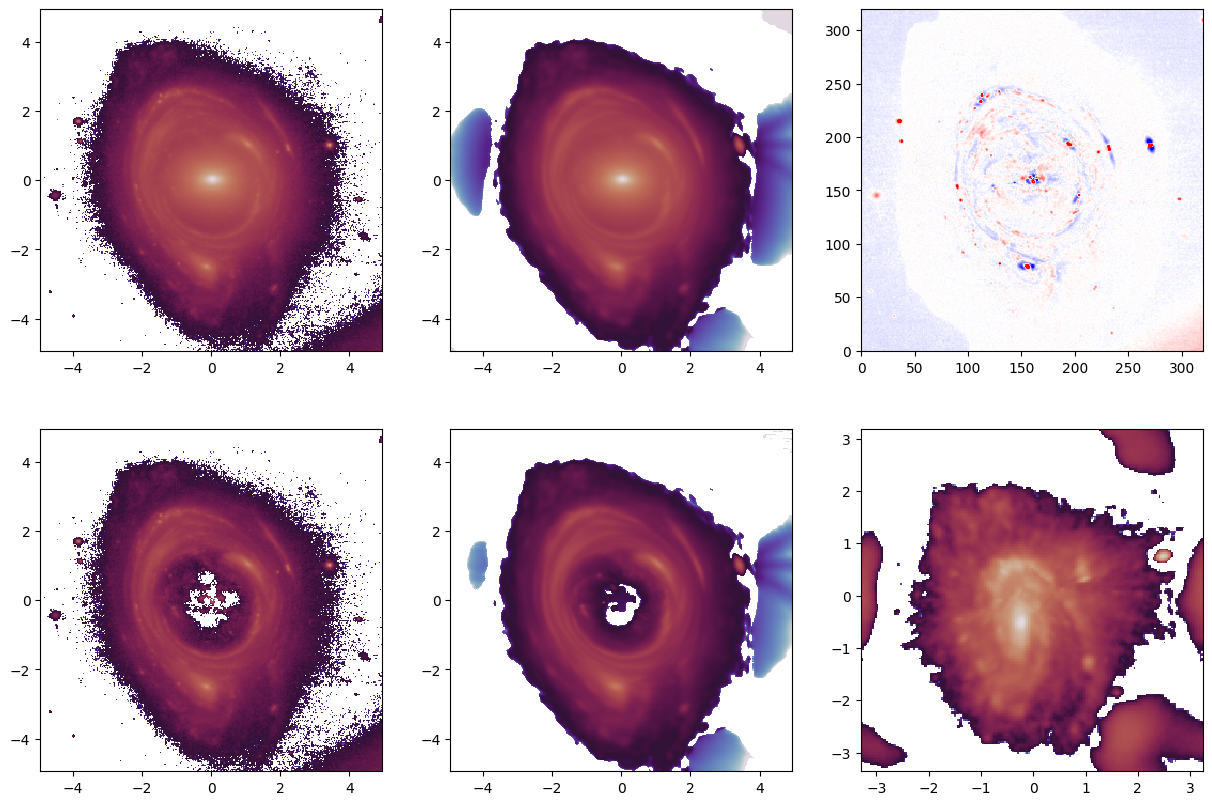

In [13]:
from matplotlib.colors import LogNorm
for i in range(4):
    log_norm = LogNorm()

    plt.figure(figsize = (15,10))
    plt.subplot(2,3,1)
    plt.imshow(data, norm = log_norm, cmap = 'twilight', extent = extent, origin = 'lower')
    plt.subplot(2,3,2)
    pic = lens_image_pixel.model(**get_value_from_index(multi_svi_pixel_median_herc, i), source_add = True,supersampled=True,unconvolved = True).reshape(reshape_size,reshape_size)
    # image_model = fftconvolve(pic, psf_x2.kernel_point_source, mode='same')
    # image_model = re_size(img_conv, 2)
    image_model = fftconvolve(pic, psf.kernel_point_source, mode='same')
    plt.imshow(image_model, norm = log_norm, cmap = 'twilight', extent = extent)
    plt.subplot(2,3,3)
    plt.imshow((data - image_model)/rms_file, cmap = 'bwr', vmax = 3, vmin = -3)
    plt.subplot(2,3,4)
    pic = lens_image_pixel.model(**get_value_from_index(multi_svi_pixel_median_herc, i), source_add = False,supersampled=True,unconvolved = True).reshape(reshape_size,reshape_size)
    # img_conv = fftconvolve(pic, psf_x2.kernel_point_source, mode='same')
    # lens_light = re_size(img_conv, 2)
    lens_light = fftconvolve(pic, psf.kernel_point_source, mode='same')
    plt.imshow(data - lens_light, norm = log_norm, cmap = 'twilight', extent = extent)

    plt.subplot(2,3,5)
    plt.imshow(image_model - lens_light, norm = log_norm, cmap = 'twilight', extent = extent)
    plt.subplot(2,3,6)
    source, source_extent = pixelize_plane_single(
        lens_image_pixel,
        get_value_from_index(multi_svi_pixel_median_herc, i),
        pixel_grid_shape,
    )
    plt.imshow(source, extent = source_extent, norm = 'log', cmap = 'twilight')

    # plt.savefig('/mnt/lustre/tianli/slice_hmc/svi_pixel'+str(i)+'.png')

### Corner plot

In [14]:
# vars_power = ['n_source_grid', 'rho_source_grid', 'sigma_source_grid']
# vars_power = ['rho_source_grid', 'sigma_source_grid']

# svi_samples_pixel = guide_pixel.sample_posterior(rng_key_, multi_svi_pixel_results.params, sample_shape=(1000,))
# svi_samples_pixel_chains = jax.tree_map(lambda x: jnp.swapaxes(x, 0, 1), svi_samples_pixel)
# svi_samples_pixel_chains = jax.device_get(svi_samples_pixel_chains)
# multi_svi_guide_sample_pixel = az.from_dict(svi_samples_pixel_chains)


In [15]:
# fig_corner = None
# for i in range(num_chains):
#     fig_corner = corner(
#         multi_svi_guide_sample_pixel.isel(chain=i),
#         var_names=vars_mass+vars_power,
#         color=f'C{i}',
#         fig=fig_corner,
#         # hist_kwargs={'density': True}
#     )

In [16]:
best_i = int(multi_svi_pixel_results.losses[:, -1000:].mean(axis=1).argmin())

# lens_light = params2kwargs_gauss_light(get_value_from_index(multi_svi_pixel_median, best_i), 'lens', N_gauss_light, sigma_lims_lens)
# import pickle

# with open('lens_light_slice.pkl', 'wb') as f:
#     pickle.dump(lens_light, f)

# vars_fixed = vars_lens_light 
# svi_pixel_median = get_value_from_index(multi_svi_pixel_median, best_i)
# fixed_params_pixel = {k:svi_pixel_median[k] for k in vars_fixed}
# model_pixel_hmc_new = condition(model_pixel_full, fixed_params_pixel)

## HMC of the pixel grid model

As with the SVI we can extend the HMC to the full pixel grid model.  Keeping the lens light and parameterized source light fixed at the parameterized SVI solution, and initialize the model with the pixelated SVI solution.  Given the complex 

In [18]:
vars_pixel = ['pixels_wn_source_grid']
vars_power = ['n_source_grid', 'rho_source_grid', 'sigma_source_grid']
multi_svi_pixel_median_vars = {k: multi_svi_pixel_median[k] for k in vars_mass + vars_power + vars_pixel + vars_other+vars_lens_light}# + 
unconstrined_svi_pixel_median = jax.vmap(lambda p: infer.util.unconstrain_fn(model_pixel_full, (data, k_grid.k), {}, p))(multi_svi_pixel_median_vars)
#unconstrined_svi_pixel_median_trim = get_value_from_indexs(unconstrined_svi_pixel_median, jnp.array([2, 5, 8, 4]))

unconstrined_svi_pixel_median = {k: v.astype(jnp.float64) for k, v in unconstrined_svi_pixel_median.items()}
rng_key, rng_key_ = jax.random.split(rng_key)

In [20]:
from numpyro.infer import NUTS, MCMC
from custom_gibbs import MultiHMCGibbs

init_fun_pixel = init_to_value_or_defer(values=get_value_from_index(multi_svi_pixel_median, 0))

inner_kernels = [
    NUTS(
        model_pixel_full,
        init_strategy=init_fun_pixel,
        target_accept_prob=0.95,
        max_tree_depth=10,
        dense_mass=[('n_source_grid', 'rho_source_grid', 'sigma_source_grid')],
    ),
    NUTS(
        model_pixel_full,
        init_strategy=init_fun_pixel,
        target_accept_prob=0.95,
        max_tree_depth=10,
        dense_mass=[('center_1',), ('theta_E_1',), ('e_1', 'gamma_1', 'gamma_sheer_1')],
    ),
]

outer_kernel = MultiHMCGibbs(
    inner_kernels,
    gibbs_sites_list=[vars_pixel+vars_power, vars_mass + vars_other] #vars_lens_light +
)

mcmc_pixel = MCMC(
    outer_kernel,
    num_warmup=50,
    num_samples=100,
    num_chains=num_chains,
    progress_bar=True,
    chain_method='vectorized'
)

batch_number = 1
last_states = []
batch_list = []
for i in range(batch_number):
    print(f'Batch {i+1}/{batch_number}')
    if i == 0:
        mcmc_pixel.run(
            rng_key_,
            data,
            k_grid.k,
            conj=False,
            init_params=unconstrined_svi_pixel_median
        )
        last_states.append(jax.device_get(mcmc_pixel.last_state))
    else:
        mcmc_pixel.post_warmup_state = mcmc_pixel.last_state
        mcmc_pixel.run(
            mcmc_pixel.post_warmup_state.rng_key,
            data,
            k_grid.k,
            conj=False
        )
        last_states.append(jax.device_get(mcmc_pixel.last_state))

    mcmc_pixel._states = jax.device_get(mcmc_pixel._states)
    mcmc_pixel._states_flat = jax.device_get(mcmc_pixel._states_flat)
    mcmc_chain = az.from_numpyro(mcmc_pixel)
    mcmc_chain.to_netcdf("/mnt/lustre/tianli/slice_hmc/slice_con_resize"+str(i)+".nc")
    batch_list.append(mcmc_chain)



Batch 1/1


sample: 100%|██████████| 150/150 [25:02<00:00, 10.01s/it]


In [21]:
import arviz as az
import numpy as np
batch_list = []
for i in range(1):
    current_batch = az.from_netcdf("/mnt/lustre/tianli/slice_hmc/slice_con_resize"+str(i)+".nc")
    batch_list.append(current_batch)
    
inf_data_pixel = az.concat(*batch_list, dim='draw')
vars_mass = ['theta_E_1', 'gamma_1', 'e_1', 'center_1', 'gamma_sheer_1']
vars_lens_light = ['A_lens', 'sigma_lens','e_lens', 'center_lens']
vars_source_light = ['A_source', 'sigma_source', 'e_source']
vars_other = []
vars_power = ['n_source_grid', 'rho_source_grid', 'sigma_source_grid']
print(f'divergences per chain per step:\n {inf_data_pixel.sample_stats.diverging.values.sum(axis=1).T}')
#az.summary(inf_data_pixel, var_names=vars_mass + vars_power + vars_other)
az.summary(inf_data_pixel.sel(chain=np.array([1,2,3])), var_names=vars_mass + vars_power + vars_other)

divergences per chain per step:
 [[33  0 25 11]
 [ 0  6  0  0]]


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
theta_E_1[0],1.921,0.001,1.919,1.924,0.001,0.000,6.0,19.0,1.51
gamma_1[0],2.390,0.009,2.375,2.398,0.005,0.002,4.0,27.0,2.00
"e_1[0, 0]",0.082,0.007,0.073,0.094,0.004,0.001,4.0,12.0,2.03
"e_1[1, 0]",-0.099,0.007,-0.111,-0.088,0.004,0.001,4.0,14.0,2.18
center_1[0],0.024,0.002,0.021,0.027,0.001,0.000,10.0,40.0,1.24
center_1[1],0.043,0.002,0.041,0.047,0.001,0.000,10.0,29.0,1.25
"gamma_sheer_1[0, 0]",-0.108,0.003,-0.110,-0.104,0.001,0.000,5.0,18.0,1.75
"gamma_sheer_1[1, 0]",-0.098,0.004,-0.103,-0.092,0.002,0.001,4.0,14.0,2.46
n_source_grid[0],0.462,0.062,0.351,0.564,0.028,0.006,5.0,18.0,1.69
rho_source_grid[0],11.627,3.954,7.744,21.150,1.976,1.765,4.0,21.0,2.45


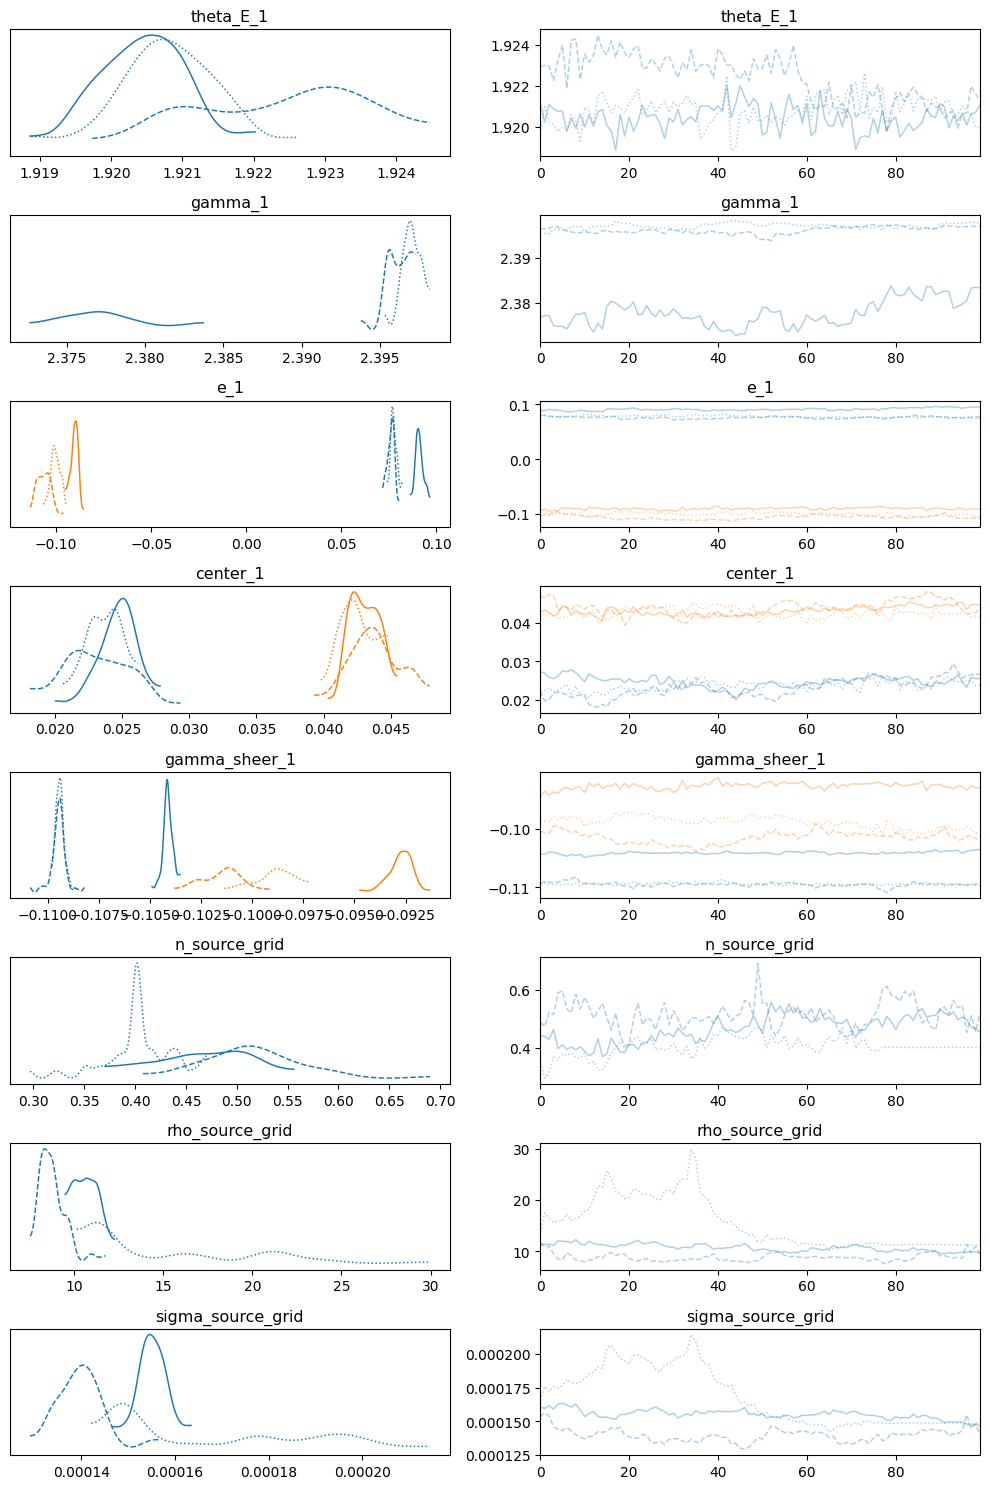

In [24]:
import matplotlib.pyplot as plt

plt.rcParams['figure.constrained_layout.use'] = True
_ = az.plot_trace(inf_data_pixel.sel(chain=np.array([1,2,3])),var_names=vars_mass + vars_power + vars_other , figsize=(10, 15))
plt.tight_layout()

In [ ]:
%load_ext autoreload
%autoreload 2
import sys
import os
import warnings
warnings.simplefilter("ignore")
from supporting_function import *
parentdir = os.path.abspath('..')
sys.path.insert(0, parentdir) 
from herculens_import_main import *
import jax
import numpyro
jax.config.update('jax_enable_x64', True)
numpyro.enable_x64()

os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
os.environ['XLA_FLAGS'] = (
    '--xla_gpu_enable_triton_softmax_fusion=true '
    '--xla_gpu_triton_gemm_any=True '
    '--xla_gpu_enable_async_collectives=true '
    '--xla_gpu_enable_latency_hiding_scheduler=true '
    '--xla_gpu_enable_highest_priority_async_stream=true '
)
if 'graphviz' not in os.environ['PATH']:
    os.environ['PATH'] = '/opt/apps/pkgs/graphviz/12.2.1/intel64/gnu_12.2.0/bin:' + os.environ['PATH']

In [ ]:
import arviz as az
import numpy as np
batch_list = []
for i in range(1):
    current_batch = az.from_netcdf("/mnt/lustre/tianli/slice_hmc/slice_con_resize"+str(i)+".nc")
    batch_list.append(current_batch)
    
inf_data_pixel = az.concat(*batch_list, dim='draw')
vars_mass = ['theta_E_1', 'gamma_1', 'e_1', 'center_1', 'gamma_sheer_1']
vars_lens_light = ['A_lens', 'sigma_lens','e_lens', 'center_lens']
vars_source_light = ['A_source', 'sigma_source', 'e_source']
vars_other = []
vars_power = ['n_source_grid', 'rho_source_grid', 'sigma_source_grid']
print(f'divergences per chain per step:\n {inf_data_pixel.sample_stats.diverging.values.sum(axis=1).T}')
#az.summary(inf_data_pixel, var_names=vars_mass + vars_power + vars_other)
az.summary(inf_data_pixel.sel(chain=np.array([0,1,2,3])), var_names=vars_mass + vars_power + vars_other)

In [ ]:
plt.rcParams['figure.constrained_layout.use'] = True
_ = az.plot_trace(inf_data_pixel, var_names=vars_mass + vars_power + vars_other , figsize=(10, 15))
plt.tight_layout()

In [ ]:
pix_scale = 0.031  # arcsec / pixel
exposure_time = 1836  # seconds

data_path = '../../Data/Slicelens/image3_sw_i2d.fits'
filename = os.path.basename(data_path)
jwst_hdu = fits.open(data_path)[1]
half = 160                                
y_jwst=2562; x_jwst=4113

data = jnp.array(jwst_hdu.data[y_jwst-half:y_jwst+half, x_jwst-half:x_jwst+half], dtype=jnp.float64)
corner_pixel = 10
background_pixels = np.vstack([data[:corner_pixel, :corner_pixel]])
data = data - np.mean(background_pixels)
rms = np.std(background_pixels)

mask = fits.getdata('../../Data/Slicelens/F150_cut_320_mask.fits')
# mask = jnp.ones_like(data)
mask = jnp.array(mask, dtype = bool)
mask_out = fits.getdata('../../Data/Slicelens/F150_cut_320_mask_out.fits')
mask_out = jnp.array(1-mask_out, dtype = bool)
mask = mask_out

npix = int(mask_out.sum())
jwst_noise = fits.open(data_path)[2]
rms_file = jnp.array(jwst_noise.data[y_jwst-half:y_jwst+half, x_jwst-half:x_jwst+half], dtype=jnp.float64)
provided_rms = True

pixel_grid, xgrid, ygrid, x_axis, y_axis, extent,nx,ny = get_pixel_grid(data, pix_scale)
psf_jwst_fits = np.load('../../Data/Slicelens/F150W_slice_psf.npy')
psf_jwst = fits.getdata('../../Data/Slicelens/jwst_nircam_f150w2_psf.fits')
psf_jwst /= np.sum(psf_jwst)

psf = PSF(psf_type='PIXEL', kernel_point_source = psf_jwst)

psf_jwst_x2 = fits.getdata('../../Data/Slicelens/jwst_nircam_F322W2_psf_ssfac2.fits')[0:199, 0:199]
psf_jwst_x2 /= np.sum(psf_jwst_x2)
psf_x2 = PSF(psf_type='PIXEL', kernel_point_source = psf_jwst_x2)


#psf = PSF(psf_type='GAUSSIAN', fwhm = 0.049, pixel_size = 0.031)
noise = Noise(nx, ny, exposure_time=exposure_time)

N_gauss_light = 15
N_gauss_source = 4

sigma_lims_lens = [0.00001, 1]
sigma_lims = [0.01, 1]

halfrange = [0.1, 0.1, 0.1]
source_grid_scale = 0.5
conj_points= jnp.array([
    [-0.155, -2.511],
    [1.054, 1.054],
])

ss_factor = 2
plotit = True

from herculens.Util.image_util import re_size
from jax.scipy.signal import fftconvolve

num_chains = 4

In [ ]:
pixel_grid_shape = 256
k_grid = K_grid((pixel_grid_shape, pixel_grid_shape))

mass_model_pixel = MassModel(['EPL', 'SHEAR'])
lens_light_model_pixel = LightModel(['GAUSSIAN_ELLIPSE'] * N_gauss_light)

source_light_model_pixel = LightModel(
    ['PIXELATED'],
    pixel_adaptive_grid=True,
    pixel_interpol='fast_bilinear',
    kwargs_pixelated={'num_pixels': pixel_grid_shape}
)

lens_image_pixel = LensImageExtension(
    deepcopy(pixel_grid),
    deepcopy(psf),
    noise_class=noise,
    lens_light_model_class=lens_light_model_pixel,
    lens_mass_model_class=mass_model_pixel,
    source_model_class=source_light_model_pixel,
    #source_arc_mask=mask,
    source_arc_mask=jnp.ones_like(data, dtype=bool),
    conjugate_points=conj_points,
    kwargs_numerics={'supersampling_factor': ss_factor},
    source_grid_scale=source_grid_scale,
)

In [ ]:
# def params2kwargs_pixel(params, fixed_params={}):
#     params_full = params | fixed_params
#     kwargs_lens = params2kwargs_EPL_w_shear(params_full, '1')
#     kwargs_source = [params2kwargs_power_spectrum(params, 'source_grid')]
#     kwargs_lens_light = params2kwargs_gauss_light(params_full, 'lens', N_gauss_light, sigma_lims_lens)
#     return {
#         'kwargs_lens': kwargs_lens,
#         'kwargs_source': kwargs_source,
#         'kwargs_lens_light': kwargs_lens_light
#     }

def params2kwargs_pixel(params, fixed_params={}):
    params_full = params | fixed_params
    kwargs_lens = params2kwargs_EPL_w_shear(params_full, '1')
    kwargs_source = [params2kwargs_power_spectrum(params, 'source_grid')]
    kwargs_lens_light = params2kwargs_gauss_light(get_value_from_index(multi_svi_pixel_median, best_i), 'lens', N_gauss_light, sigma_lims_lens)
    return {
        'kwargs_lens': kwargs_lens,
        'kwargs_source': kwargs_source,
        'kwargs_lens_light': kwargs_lens_light
    }

hmc_median_pixel = inf_data_pixel.posterior.median(dim=('chain', 'draw'))
hmc_std_pixel = inf_data_pixel.posterior.std(dim=('chain', 'draw'))

hmc_median_pixel = {k: v.data for k, v in hmc_median_pixel.data_vars.items()}
hmc_median_pixel_herc = params2kwargs_pixel(hmc_median_pixel)#, fixed_params=fixed_params_pixel)

hmc_median_pixel_by_chain = inf_data_pixel.posterior.median(dim=('draw'))

hmc_median_pixel_by_chain = {k: v.data for k, v in hmc_median_pixel_by_chain.data_vars.items()}

hmc_median_pixel_herc_by_chian = median_params2kwargs(
    partial(params2kwargs_pixel),
    hmc_median_pixel_by_chain,
    jnp.arange(num_chains)
)

In [ ]:
for i in range(5):
    if i == 0:
        result_post = hmc_median_pixel_herc
    else:
        result_post = get_value_from_index(hmc_median_pixel_herc_by_chian, i+1)
    plt.figure(figsize = (15,10))
    plt.subplot(2,3,1)
    plt.imshow(data, norm = 'log', cmap = 'twilight', extent = extent, origin = 'lower', vmax = 1e2, vmin = 1e-5)
    plt.colorbar()
    plt.subplot(2,3,2)
    pic = lens_image_pixel.model(**result_post, source_add = True,supersampled=True,unconvolved = True).reshape(reshape_size,reshape_size)
    image_model = fftconvolve(pic, psf.kernel_point_source, mode='same')
    # img_conv = fftconvolve(pic, psf_x2.kernel_point_source, mode='same')
    # image_model = re_size(img_conv, 2)
    plt.imshow(image_model, norm = 'log', cmap = 'twilight', extent = extent, vmax = 1e2, vmin = 1e-5)
    plt.subplot(2,3,3)
    plt.imshow((data - image_model)/rms_file, cmap = 'bwr', vmax = 3, vmin = -3, extent=extent)
    plt.contour(mask, levels=[0.5], colors='#ff3300', alpha = 0.95, linestyles='dashed', origin='lower', extent=extent)
    plt.contour(mask_out, levels=[0.5], colors='#9933ff', alpha = 0.95, linestyles='dashed', origin='lower', extent=extent)
    plt.subplot(2,3,4)
    pic = lens_image_pixel.model(**result_post, source_add = False,supersampled=True,unconvolved = True).reshape(reshape_size,reshape_size)
    lens_light = fftconvolve(pic, psf.kernel_point_source, mode='same')
    # img_conv = fftconvolve(pic, psf_x2.kernel_point_source, mode='same')
    # lens_light = re_size(img_conv, 2)
    plt.imshow(data - lens_light, norm = 'log', cmap = 'twilight', extent = extent, vmax = 1e1, vmin = 1e-5)

    plt.subplot(2,3,5)
    plt.imshow(image_model - lens_light, norm = 'log', cmap = 'twilight', extent = extent, vmax = 1e1, vmin = 1e-5)
    plt.subplot(2,3,6)
    source, source_extent = pixelize_plane_single(
        lens_image_pixel,
        result_post,
        pixel_grid_shape,
    )
    plt.imshow(source, extent = source_extent, norm = 'log', cmap = 'twilight')

In [ ]:
fig_corner = None
for i in range(num_chains):
     fig_corner = corner(
         inf_data_pixel.isel(chain=i),
         var_names=vars_mass + vars_other,
         color = f'C{i}',
         fig=fig_corner,
         hist_kwargs={'density': True}
     )

